# Анализ данных, визуализация и проверка гипотез

Метрика соревнования: RMSE между логарифмом предсказания и логарифмом реальной цены. В этом ноутбуке изучаем данные и формулируем гипотезы, которые проверим в следующих ноутбуках: предобработка, feature engineering, модели

## 1. Загрузка данных и первичный обзор

In [42]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

sns.set_theme(style="darkgrid")
pd.set_option("display.max_columns", 100)

DATA_DIR = Path("../data")
TARGET = "SalePrice"

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

print(f"train: {train.shape}, test: {test.shape}")
print(f"колонки только в train: {set(train.columns) - set(test.columns)}")

train: (1460, 81), test: (1459, 80)
колонки только в train: {'SalePrice'}


In [43]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [44]:
train.dtypes.value_counts()

str        43
int64      35
float64     3
Name: count, dtype: int64

### Пропуски

В описании данных `NA` в ряде колонок означает "объекта нет", например нет бассейна, гаража или подвала, а не потерянное значение. Pandas при чтении превращает такие значения в `NaN`, поэтому сначала посмотрим на пропуски в сыром виде, а потом разделим их на два типа

In [45]:
def missing_summary(train_df: pd.DataFrame, test_df: pd.DataFrame) -> pd.DataFrame:
    """Сводка по пропускам в train и test.

    Возвращает таблицу только с колонками, где есть хотя бы один пропуск
    в одной из выборок: количество пропусков и их процент от числа строк
    отдельно для train и test
    """
    summary = pd.DataFrame(
        {
            "train_missing_count": train_df.isna().sum(),
            "train_missing_pct": (train_df.isna().mean() * 100).round(1),
            "test_missing_count": test_df.isna().sum().reindex(train_df.columns),
            "test_missing_pct": (test_df.isna().mean() * 100).reindex(train_df.columns).round(1),
        }
    )
    has_missing = (summary["train_missing_count"] > 0) | (summary["test_missing_count"] > 0)
    return summary[has_missing].sort_values("train_missing_count", ascending=False)


missing = missing_summary(train, test)
print(f"колонок с пропусками: {len(missing)}")
missing

колонок с пропусками: 34


,train_missing_count,train_missing_pct,test_missing_count,test_missing_pct
PoolQC,1453,99.5,1456.0,99.8
MiscFeature,1406,96.3,1408.0,96.5
Alley,1369,93.8,1352.0,92.7
Fence,1179,80.8,1169.0,80.1
MasVnrType,872,59.7,894.0,61.3
FireplaceQu,690,47.3,730.0,50.0
LotFrontage,259,17.7,227.0,15.6
GarageYrBlt,81,5.5,78.0,5.3
GarageFinish,81,5.5,78.0,5.3
GarageCond,81,5.5,78.0,5.3


### Пропуск или отсутствие объекта

У многих колонок с пропусками есть числовая пара, которая говорит, существует ли объект: `PoolArea` для `PoolQC`, `GarageArea` для гаражных колонок, `TotalBsmtSF` для подвальных, `Fireplaces` для `FireplaceQu`, `MiscVal` для `MiscFeature`, `MasVnrArea` для `MasVnrType`. Если в такой колонке `NaN`, а в паре ноль, значит объекта нет и это осознанное значение. Если в паре число больше нуля, то значение действительно потеряно

Для `Alley` и `Fence` числовой пары нет, но по описанию данных `NA` в них тоже означает отсутствие

In [46]:
GARAGE_COLUMNS = ["GarageType", "GarageFinish", "GarageQual", "GarageCond", "GarageYrBlt"]
BASEMENT_COLUMNS = ["BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"]

EXISTENCE_INDICATORS = {
    "PoolQC": "PoolArea",
    "FireplaceQu": "Fireplaces",
    "MiscFeature": "MiscVal",
    "MasVnrType": "MasVnrArea",
    **{column: "GarageArea" for column in GARAGE_COLUMNS},
    **{column: "TotalBsmtSF" for column in BASEMENT_COLUMNS},
}


def check_missing_vs_existence(df: pd.DataFrame, indicators: dict[str, str]) -> pd.DataFrame:
    """Выясняет, какие пропуски означают отсутствие объекта, а какие потерянное значение.

    indicators сопоставляет колонку с пропусками числовой колонке, которая
    показывает, есть ли объект, например PoolQC и PoolArea. Для каждой колонки
    считает, сколько пропусков приходится на нулевое значение индикатора
    (object_absent, объекта нет), на положительное значение
    (real_missing, значение потеряно) и на пропуск в самом индикаторе (indicator_nan)
    """
    rows = {}
    for column, indicator in indicators.items():
        is_missing = df[column].isna()
        rows[column] = {
            "indicator": indicator,
            "missing": is_missing.sum(),
            "object_absent": (is_missing & (df[indicator] == 0)).sum(),
            "real_missing": (is_missing & (df[indicator] > 0)).sum(),
            "indicator_nan": (is_missing & df[indicator].isna()).sum(),
        }
    return pd.DataFrame.from_dict(rows, orient="index")


pd.concat(
    {
        "train": check_missing_vs_existence(train, EXISTENCE_INDICATORS),
        "test": check_missing_vs_existence(test, EXISTENCE_INDICATORS),
    },
    axis=1,
)

train                                                   \
                indicator missing object_absent real_missing indicator_nan   
PoolQC           PoolArea    1453          1453            0             0   
FireplaceQu    Fireplaces     690           690            0             0   
MiscFeature       MiscVal    1406          1406            0             0   
MasVnrType     MasVnrArea     872           859            5             8   
GarageType     GarageArea      81            81            0             0   
GarageFinish   GarageArea      81            81            0             0   
GarageQual     GarageArea      81            81            0             0   
GarageCond     GarageArea      81            81            0             0   
GarageYrBlt    GarageArea      81            81            0             0   
BsmtQual      TotalBsmtSF      37            37            0             0   
BsmtCond      TotalBsmtSF      37            37            0             0   
BsmtExposure  TotalBsmtSF      38            37            1             0   
BsmtFinType1  TotalBsmtSF      37            37            0             0   
BsmtFinType2  TotalBsmtSF      38            37            1             0   

                     test                                                   
                indicator missing object_absent real_missing indicator_nan  
PoolQC           PoolArea    1456          1453            3             0  
FireplaceQu    Fireplaces     730           730            0             0  
MiscFeature       MiscVal    1408          1407            1             0  
MasVnrType     MasVnrArea     894           876            3            15  
GarageType     GarageArea      76            76            0             0  
GarageFinish   GarageArea      78            76            1             1  
GarageQual     GarageArea      78            76            1             1  
GarageCond     GarageArea      78            76            1             1  
GarageYrBlt    GarageArea      78            76            1             1  
BsmtQual      TotalBsmtSF      44            41            2             1  
BsmtCond      TotalBsmtSF      45            41            3             1  
BsmtExposure  TotalBsmtSF      44            41            2             1  
BsmtFinType1  TotalBsmtSF      42            41            0             1  
BsmtFinType2  TotalBsmtSF      42            41            0             1

In [47]:
raw_train = pd.read_csv(DATA_DIR / "train.csv", keep_default_na=False)
raw_test = pd.read_csv(DATA_DIR / "test.csv", keep_default_na=False)

pd.DataFrame(
    {
        "train": raw_train["MasVnrType"].value_counts(),
        "test": raw_test["MasVnrType"].value_counts(),
    }
).fillna(0).astype(int)

,train,test
MasVnrType,,
BrkCmn,15,10
BrkFace,445,434
NA,8,16
None,864,878
Stone,128,121


### Выводы по пропускам

- Почти все пропуски в `PoolQC`, `FireplaceQu`, `MiscFeature`, гаражных и подвальных колонках совпадают с нулём в парной колонке, то есть объекта нет. Такие значения нельзя заполнять модой или медианой, это отдельная категория отсутствия
- Внутри этих же групп есть настоящие пропуски, в основном в test: три дома с бассейном без `PoolQC`, один дом с `MiscVal` без `MiscFeature`, по одному или два дома с гаражом без отделки, качества и года, два или три дома с подвалом без части описаний. В train таких случаев всего два: `BsmtExposure` и `BsmtFinType2` по одному дому. Их нужно заполнять как обычные пропуски, а не категорией отсутствия
- В `MasVnrType` слово `None` это настоящая категория, а пропуск в сыром файле записан как `NA`: 864 и 8 строк в train, 878 и 16 в test. Чтение по умолчанию склеивает эти два случая, поэтому такую колонку придётся читать отдельно или разделять вручную. Ещё из 864 домов с типом `None` у 859 площадь облицовки нулевая, а у пяти положительная, это несостыковка в данных
- `LotFrontage` не имеет пары, которая объясняла бы пропуск, поэтому считаем его настоящим пропуском, как и `Electrical` и `MasVnrArea`. Для `Alley` и `Fence` числовой пары нет, но по описанию данных `NA` означает отсутствие

## 2. Целевая переменная SalePrice

Метрика считается на логарифме цены, поэтому важно понять, как распределена сама цена и как меняется распределение после `log1p`

In [48]:
train[TARGET].describe().round(0)

count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64

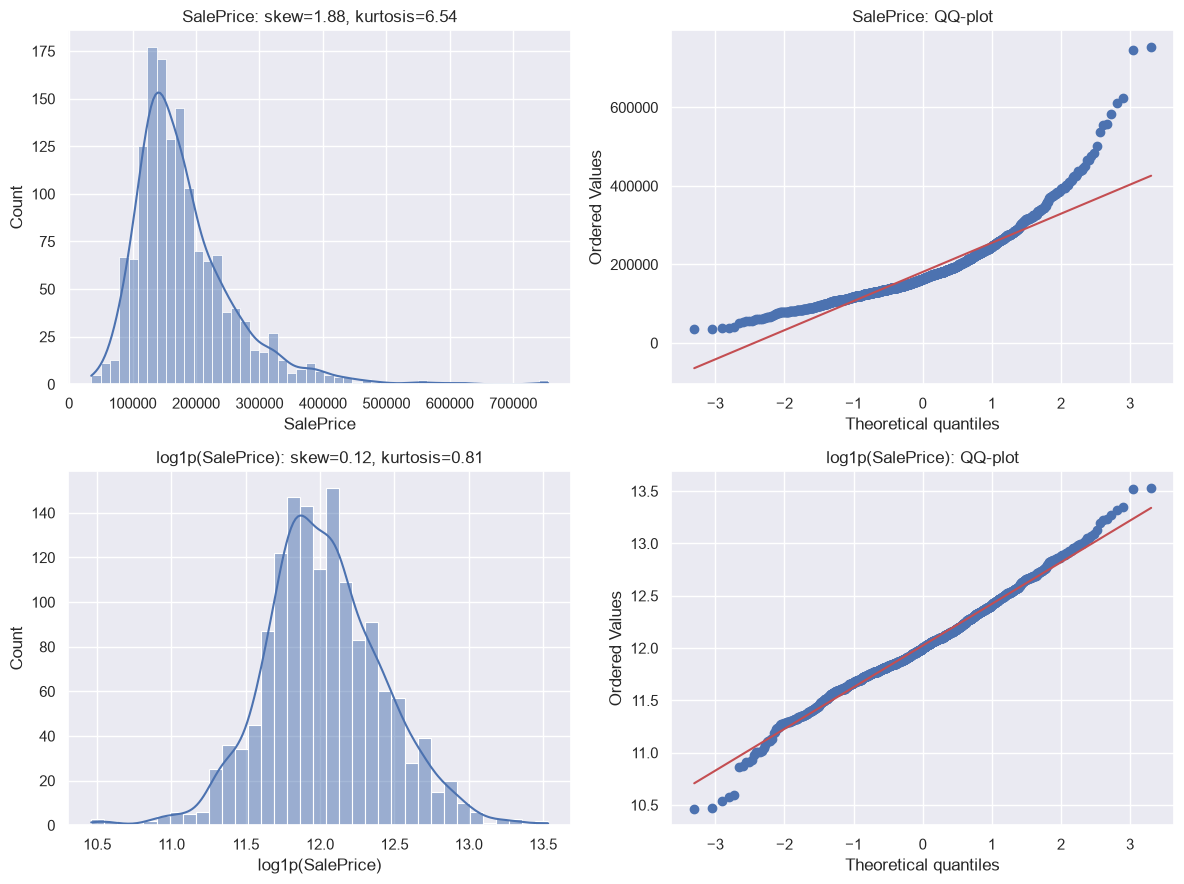

In [49]:
def plot_distribution_and_qq(series: pd.Series, title: str, axes) -> None:
    """Рисует гистограмму с плотностью и QQ-график против нормального распределения.

    В заголовок гистограммы выводятся скошенность и эксцесс. axes это пара осей:
    на первую идёт гистограмма, на вторую QQ-график
    """
    sns.histplot(series, kde=True, ax=axes[0])
    axes[0].set_title(f"{title}: skew={series.skew():.2f}, kurtosis={series.kurt():.2f}")
    axes[0].set_xlabel(title)
    stats.probplot(series, dist="norm", plot=axes[1])
    axes[1].set_title(f"{title}: QQ-plot")


fig, axes = plt.subplots(2, 2, figsize=(12, 9))
plot_distribution_and_qq(train[TARGET], TARGET, axes[0])
plot_distribution_and_qq(np.log1p(train[TARGET]), f"log1p({TARGET})", axes[1])
plt.tight_layout()
plt.show()

### Выводы по таргету

- Цена сильно скошена вправо: скошенность 1.88, эксцесс 6.54. Большинство домов стоит от 130 до 215 тысяч долларов, а хвост тянется до 755 тысяч. На QQ-графике правый хвост сильно уходит вверх от прямой, а в левой части точки лежат выше прямой
- После `log1p` скошенность падает до 0.12, эксцесс до 0.81, распределение становится близким к нормальному, и точки на QQ-графике почти ложатся на прямую. Небольшие отклонения остаются только на самых дешёвых и самых дорогих домах
- Это согласуется с метрикой: ошибка считается на логарифме, поэтому модели будем обучать на `log1p(SalePrice)`, а в сабмите возвращать `expm1` от предсказаний. Для линейных моделей это ещё и выравнивает распределение остатков
- Гипотеза для проверки в следующих ноутбуках: обучение на логарифме улучшит RMSE по сравнению с обучением на исходной цене

## 3. Числовые признаки

Из числовых колонок исключаем `Id` и `MSSubClass`: первая это просто номер, а вторая хоть и записана числом, по описанию данных является кодом категории, поэтому разберём её вместе с категориальными признаками. Оценки качества `OverallQual` и `OverallCond` оставляем числовыми, у них есть естественный порядок

### Связь с таргетом

Начинаем с обычной матрицы корреляций числовых признаков вместе с ценой, сырой и логарифмированной, и смотрим на её столбцы с таргетом

In [50]:
NON_FEATURE_NUMERIC = {"Id", "MSSubClass", TARGET}
NUMERIC_COLUMNS = [
    column for column in train.select_dtypes("number").columns if column not in NON_FEATURE_NUMERIC
]
log_target = np.log1p(train[TARGET])

numeric_data = train[NUMERIC_COLUMNS].assign(SalePrice=train[TARGET], LogSalePrice=log_target)
corr_matrix = numeric_data.corr()
default_corr = (
    corr_matrix[["SalePrice", "LogSalePrice"]]
    .drop(index=["SalePrice", "LogSalePrice"])
    .sort_values("LogSalePrice", ascending=False)
)
default_corr.style.background_gradient(cmap="coolwarm", vmin=-1, vmax=1).format("{:.2f}")

,SalePrice,LogSalePrice
OverallQual,0.79,0.82
GrLivArea,0.71,0.70
GarageCars,0.64,0.68
GarageArea,0.62,0.65
TotalBsmtSF,0.61,0.61
1stFlrSF,0.61,0.60
FullBath,0.56,0.59
YearBuilt,0.52,0.59
YearRemodAdd,0.51,0.57
GarageYrBlt,0.49,0.54


Столбцы `SalePrice` и `LogSalePrice` это корреляция каждого признака с сырой ценой и с логарифмом цены. Стандартная матрица корреляций считает коэффициент Пирсона, то есть ловит только линейную связь. Цвет ячейки показывает знак и силу связи: красный для положительной, синий для отрицательной. Строки отсортированы по корреляции с логарифмом, так как именно на нём считается метрика

### Гипотеза о нелинейной связи

Часть признаков связана с ценой слабее, чем можно ожидать. Например, размер участка `LotArea` имеет корреляцию всего около 0.26, хотя интуитивно должен влиять сильнее. Возможно, связь есть, но она не линейная или искажена выбросами, и коэффициент Пирсона её недооценивает

Проверим это через корреляцию Спирмена. Она считается по рангам значений, поэтому ловит любую монотонную связь, а не только линейную, и меньше зависит от выбросов. Если у признака корреляция Спирмена заметно выше, чем Пирсона, значит связь с ценой монотонная, но нелинейная. Ранги не меняются от логарифма цены, поэтому для сырой и логарифмированной цены корреляция Спирмена одна и та же

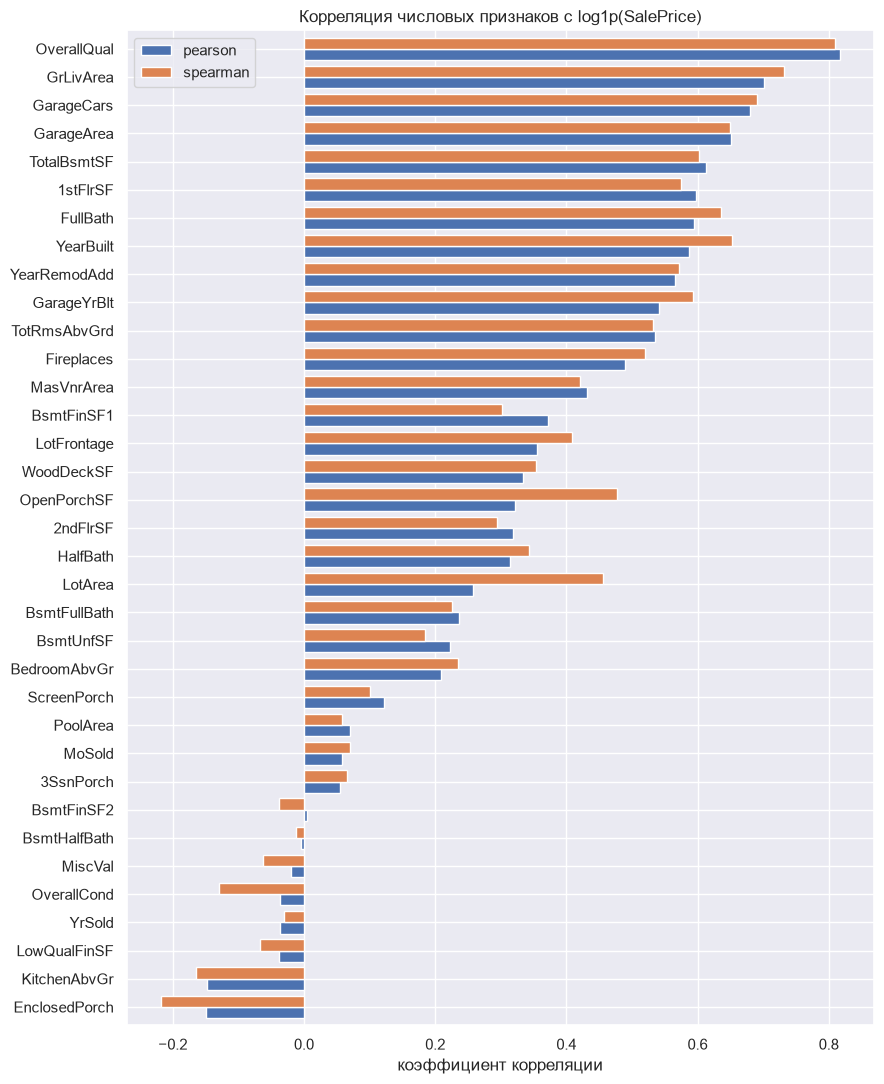

In [51]:
def target_correlations(df: pd.DataFrame, columns: list[str], target: pd.Series) -> pd.DataFrame:
    """Считает корреляции Пирсона и Спирмена каждой колонки с таргетом.

    Пропуски в колонках игнорируются попарно. Результат отсортирован
    по убыванию корреляции Пирсона
    """
    correlations = pd.DataFrame(
        {
            "pearson": df[columns].corrwith(target, method="pearson"),
            "spearman": df[columns].corrwith(target, method="spearman"),
        }
    )
    return correlations.sort_values("pearson", ascending=False)


correlations = target_correlations(train, NUMERIC_COLUMNS, log_target)
correlations.iloc[::-1].plot.barh(figsize=(9, 11), width=0.8)
plt.title("Корреляция числовых признаков с log1p(SalePrice)")
plt.xlabel("коэффициент корреляции")
plt.tight_layout()
plt.show()

Те же корреляции в виде таблицы, чтобы видеть точные числа. Столбец `pearson_raw_price` добавлен для сравнения: это корреляция Пирсона с ценой без логарифма. Корреляция Спирмена считается по рангам, поэтому для сырой и логарифмической цены она одинакова. Цвет ячейки показывает знак и силу связи: красный для положительной, синий для отрицательной

In [52]:
correlations_table = correlations.rename(columns={"pearson": "pearson_log_price"}).assign(
    pearson_raw_price=train[NUMERIC_COLUMNS].corrwith(train[TARGET])
)
correlations_table.style.background_gradient(cmap="coolwarm", vmin=-1, vmax=1).format("{:.2f}")

,pearson_log_price,spearman,pearson_raw_price
OverallQual,0.82,0.81,0.79
GrLivArea,0.70,0.73,0.71
GarageCars,0.68,0.69,0.64
GarageArea,0.65,0.65,0.62
TotalBsmtSF,0.61,0.60,0.61
1stFlrSF,0.60,0.58,0.61
FullBath,0.59,0.64,0.56
YearBuilt,0.59,0.65,0.52
YearRemodAdd,0.57,0.57,0.51
GarageYrBlt,0.54,0.59,0.49


### Выводы по корреляциям с таргетом

- Сильнее всего с ценой связано качество отделки `OverallQual`, корреляция около 0.82. Дальше идут жилая площадь `GrLivArea` 0.70, вместимость и площадь гаража `GarageCars` и `GarageArea` 0.68 и 0.65, площадь подвала `TotalBsmtSF` 0.61
- Признаки года постройки, реконструкции и года гаража `YearBuilt`, `YearRemodAdd`, `GarageYrBlt` связаны с ценой на уровне 0.54 до 0.59, новые дома дороже. Гипотеза: возраст дома `YrSold - YearBuilt` будет полезнее самих годов
- Гипотеза о нелинейной связи подтвердилась для части признаков. У `LotArea` корреляция Спирмена 0.46, а Пирсона всего 0.26, у `OpenPorchSF` 0.48 против 0.32. Связь с ценой есть, но она нелинейная или искажена выбросами. Гипотеза: логарифм этих признаков улучшит линейные модели
- Почти нулевая связь у `MiscVal`, `YrSold`, `MoSold`, `LowQualFinSF`, `BsmtHalfBath`, `BsmtFinSF2`, `PoolArea`, `3SsnPorch`. Сами по себе они слабые, но это не значит, что бесполезны в комбинации с другими признаками, поэтому не выбрасываем их по одной корреляции
- Отрицательная связь у `KitchenAbvGr` и `EnclosedPorch`, около минус 0.15. Общее состояние дома `OverallCond` связано с ценой слабо, минус 0.04 по Пирсону и минус 0.13 по Спирмену, то есть цену определяет качество, а не износ
- Корреляции Пирсона и Спирмена по большинству признаков близки, значит связи в основном монотонные и близкие к линейным
- Сырая и логарифмированная цена дают близкие корреляции Пирсона. Заметнее всего различаются признаки года, они связаны с логарифмом цены сильнее на 0.05 до 0.06

### Скоррелированные признаки

Если два признака сильно коррелируют между собой, они несут почти одну и ту же информацию. Для деревьев и бустингов это не страшно, а линейные модели становятся нестабильными: коэффициенты прыгают, а регуляризация вынуждена делить вес между дублями. Найдём пары числовых признаков с корреляцией по модулю от 0.6 и рядом посмотрим, как каждый из пары связан с ценой

In [53]:
def correlated_pairs(df: pd.DataFrame, columns: list[str], target: pd.Series, threshold: float = 0.6) -> pd.DataFrame:
    """Находит пары признаков, у которых корреляция по модулю не меньше порога.

    Каждая пара встречается один раз. Для обоих признаков пары добавлена
    корреляция с таргетом, чтобы было видно, какой из двух полезнее.
    Результат отсортирован по убыванию модуля корреляции внутри пары
    """
    corr = df[columns].corr()
    upper_triangle = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
    pairs = upper_triangle[upper_triangle.abs() >= threshold].reset_index()
    pairs.columns = ["feature_1", "feature_2", "corr"]

    target_corr = df[columns].corrwith(target)
    pairs["target_corr_1"] = pairs["feature_1"].map(target_corr)
    pairs["target_corr_2"] = pairs["feature_2"].map(target_corr)
    return pairs.sort_values("corr", key=abs, ascending=False).reset_index(drop=True)


pairs = correlated_pairs(train, NUMERIC_COLUMNS, log_target)
pairs.round(2)

,feature_1,feature_2,corr,target_corr_1,target_corr_2
0,GarageCars,GarageArea,0.88,0.68,0.65
1,YearBuilt,GarageYrBlt,0.83,0.59,0.54
2,GrLivArea,TotRmsAbvGrd,0.83,0.70,0.53
3,TotalBsmtSF,1stFlrSF,0.82,0.61,0.60
4,2ndFlrSF,GrLivArea,0.69,0.32,0.70
5,BedroomAbvGr,TotRmsAbvGrd,0.68,0.21,0.53
6,BsmtFinSF1,BsmtFullBath,0.65,0.37,0.24
7,YearRemodAdd,GarageYrBlt,0.64,0.57,0.54
8,GrLivArea,FullBath,0.63,0.70,0.59
9,2ndFlrSF,TotRmsAbvGrd,0.62,0.32,0.53


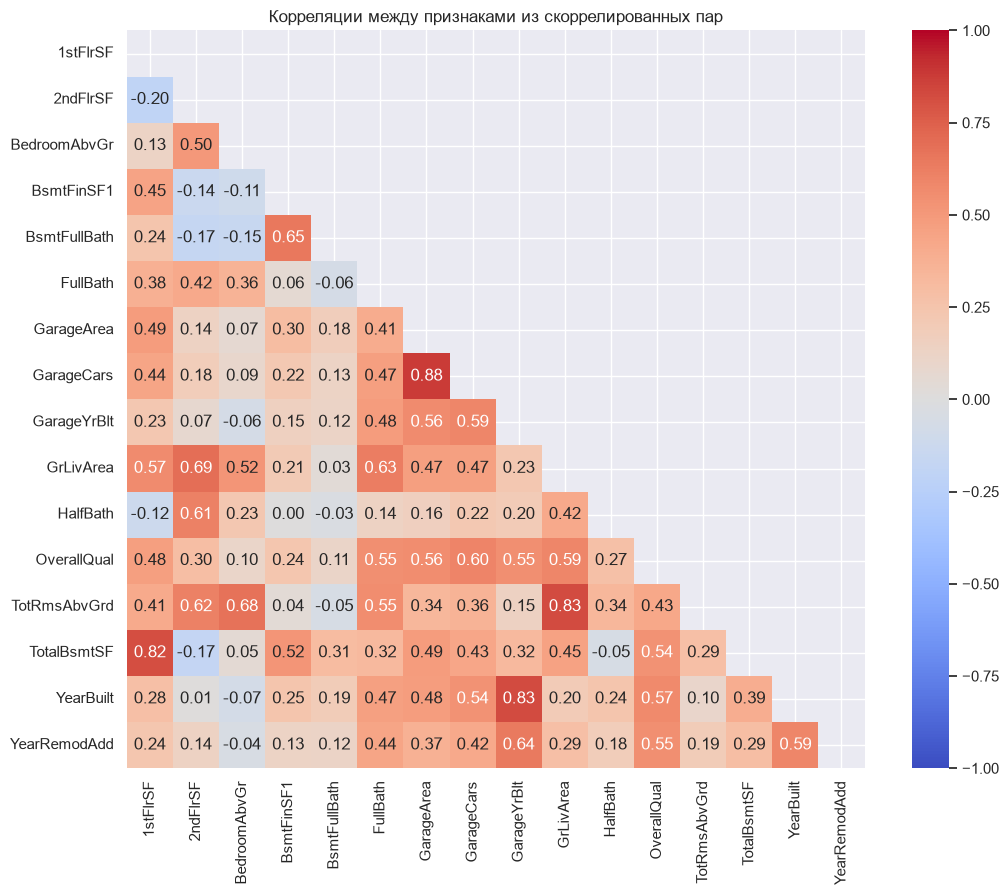

In [54]:
pair_columns = sorted(set(pairs["feature_1"]) | set(pairs["feature_2"]))
pair_corr = train[pair_columns].corr()
upper_mask = np.triu(np.ones_like(pair_corr, dtype=bool))

plt.figure(figsize=(11, 9))
sns.heatmap(pair_corr, mask=upper_mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Корреляции между признаками из скоррелированных пар")
plt.tight_layout()
plt.show()

In [55]:
floors_sum = train["1stFlrSF"] + train["2ndFlrSF"] + train["LowQualFinSF"]
print(f"GrLivArea равен сумме 1stFlrSF, 2ndFlrSF и LowQualFinSF в {(floors_sum == train['GrLivArea']).mean():.0%} домов")

has_garage = train["GarageYrBlt"].notna()
same_year = train.loc[has_garage, "GarageYrBlt"] == train.loc[has_garage, "YearBuilt"]
print(f"GarageYrBlt совпадает с YearBuilt в {same_year.mean():.0%} домов с гаражом")

GrLivArea равен сумме 1stFlrSF, 2ndFlrSF и LowQualFinSF в 100% домов
GarageYrBlt совпадает с YearBuilt в 79% домов с гаражом


### Выводы по скоррелированным признакам

- Самые сильные пары: `GarageCars` и `GarageArea` 0.88, `YearBuilt` и `GarageYrBlt` 0.83, `GrLivArea` и `TotRmsAbvGrd` 0.83, `TotalBsmtSF` и `1stFlrSF` 0.82. Внутри каждой пары признаки почти дублируют друг друга
- Гараж: `GarageCars` и `GarageArea` связаны с ценой почти одинаково, 0.68 и 0.65, поэтому для линейных моделей можно оставить один
- Год гаража `GarageYrBlt` совпадает с `YearBuilt` в 79% домов с гаражом, при этом у него есть 81 пропуск и связь с ценой слабее, 0.54 против 0.59. Кандидат на удаление
- `TotRmsAbvGrd` связан с ценой слабее, чем `GrLivArea`, 0.53 против 0.70, и почти повторяет его, потому что чем больше площадь, тем больше комнат. Кандидат на удаление
- `TotalBsmtSF` и `1stFlrSF` связаны с ценой одинаково, 0.61 и 0.60. Вместе они дают идею составного признака общей площади
- `GrLivArea` в точности равен сумме площадей `1stFlrSF`, `2ndFlrSF` и `LowQualFinSF`, это верно для всех строк train. Поэтому его корреляция с `2ndFlrSF`, 0.69, объясняется самой конструкцией признака
- Гипотезы для проверки в следующих ноутбуках: составной признак общей площади `TotalBsmtSF + GrLivArea` полезнее отдельных площадей, а удаление `GarageArea`, `GarageYrBlt`, `TotRmsAbvGrd` и `1stFlrSF` не ухудшит метрику линейных моделей. Для деревьев и бустингов эффект скорее всего будет нулевым

### Константные и почти константные признаки

Признак, у которого почти все значения одинаковые, практически не различает дома и может только добавить шум. Считаем для каждой колонки, какую долю занимает самое частое значение, и смотрим на колонки, где эта доля не меньше 0.9. Пропуски считаем отдельным значением, потому что, как выяснили выше, они часто означают отсутствие объекта

In [56]:
def dominant_value_share(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Считает, какую долю занимает самое частое значение в каждой колонке.

    Пропуск считается отдельным значением. Возвращает самое частое значение,
    его долю и число уникальных значений для каждой колонки
    """
    rows = {}
    for column in columns:
        shares = df[column].value_counts(normalize=True, dropna=False)
        rows[column] = {
            "top_value": shares.index[0],
            "top_share": shares.iloc[0],
            "n_unique": df[column].nunique(dropna=False),
        }
    return pd.DataFrame.from_dict(rows, orient="index")


feature_columns = [column for column in train.columns if column not in {"Id", TARGET}]
dominance = dominant_value_share(train, feature_columns)
near_constant = dominance[dominance["top_share"] >= 0.9].sort_values("top_share", ascending=False)
near_constant["test_top_share"] = dominant_value_share(test, near_constant.index.tolist())["top_share"]
print(f"колонок с долей самого частого значения от 0.9: {len(near_constant)} из {len(feature_columns)}")
near_constant.round(3)

колонок с долей самого частого значения от 0.9: 21 из 79


,top_value,top_share,n_unique,test_top_share
Utilities,AllPub,0.999,2,0.999
Street,Pave,0.996,2,0.996
PoolArea,0,0.995,8,0.996
PoolQC,NaN,0.995,4,0.998
Condition2,Norm,0.990,8,0.990
3SsnPorch,0,0.984,20,0.991
RoofMatl,CompShg,0.982,8,0.988
LowQualFinSF,0,0.982,24,0.990
Heating,GasA,0.978,6,0.991
MiscVal,0,0.964,21,0.965


Редкое значение может нести сигнал, даже если его мало. Для каждой почти константной колонки посмотрим, сколько домов имеют не самое частое значение и чем отличается их медианная цена

In [57]:
def price_by_dominance(df: pd.DataFrame, columns: list[str], target_column: str) -> pd.DataFrame:
    """Сравнивает медианную цену домов с самым частым значением и с остальными.

    Для каждой колонки возвращает число домов с редким значением и медианную цену
    двух групп. Пропуск считается отдельным значением
    """
    rows = {}
    for column in columns:
        top_value = df[column].value_counts(dropna=False).index[0]
        is_top = df[column].isna() if pd.isna(top_value) else df[column] == top_value
        rows[column] = {
            "other_count": (~is_top).sum(),
            "median_price_top": df.loc[is_top, target_column].median(),
            "median_price_other": df.loc[~is_top, target_column].median(),
        }
    return pd.DataFrame.from_dict(rows, orient="index")


price_by_dominance(train, near_constant.index.tolist(), TARGET)

,other_count,median_price_top,median_price_other
Utilities,1,163000.0,137500.0
Street,6,163000.0,114250.0
PoolArea,7,162900.0,235000.0
PoolQC,7,162900.0,235000.0
Condition2,15,163500.0,128000.0
3SsnPorch,24,162000.0,187500.0
RoofMatl,26,162000.0,234750.0
LowQualFinSF,26,163945.0,131500.0
Heating,32,164500.0,116750.0
MiscVal,52,164000.0,148000.0


### Выводы по константным признакам

- Абсолютно константных колонок нет, но 21 колонка из 79 имеет самое частое значение у 90% домов и больше. Доли в train и test почти совпадают, значит признаки одинаково вырождены в обеих выборках
- Практически константы: `Utilities` 99.9%, `Street` 99.6%, `Condition2` 99%, `RoofMatl` 98.2%, `Heating` 97.8%. У `Utilities` всего один дом с другим значением, на одном примере учиться нельзя, поэтому колонка первый кандидат на удаление
- Бассейн, `PoolArea` и `PoolQC`, есть только у 7 домов из 1460, у `MiscVal` и `MiscFeature` редкое значение у 52 и 54 домов. Гипотеза: вместо площади и качества лучше сделать бинарные флаги наличия бассейна и прочих особенностей
- Редкое значение может нести сигнал, поэтому удалять колонки только по доле нельзя. Медианная цена домов с редким значением заметно отличается у многих колонок: `CentralAir` со значением `N` у 95 домов, 98 тысяч против 168 тысяч, `Heating` не `GasA` у 32 домов, 117 тысяч против 165 тысяч, `KitchenAbvGr` не равный 1 у 68 домов, 129 тысяч против 166 тысяч, `RoofMatl` не `CompShg` у 26 домов, 235 тысяч против 162 тысяч
- `CentralAir` со значением `Y` у 93.5% домов в train и 93.1% в test, то есть распределение в обеих выборках совпадает и странностей не видно. При этом колонка информативная, дома без центрального кондиционирования заметно дешевле
- Гипотеза для проверки в следующих ноутбуках: удаление `Utilities` не ухудшит метрику, а для остальных почти константных колонок лучше объединять редкие категории или заводить бинарные флаги, чем удалять

### Скошенность числовых признаков

Многие признаки площадей имеют длинный правый хвост: несколько огромных домов и участков на фоне массы обычных. Для линейных моделей и нейросетей это плохо, потому что выбросы в хвосте сильно влияют на коэффициенты. Стандартное лечение это логарифм `log1p`, он подходит, пока значения неотрицательные, а в наших числовых колонках отрицательных нет

Для колонок со скошенностью по модулю от 0.75 сравним скошенность и корреляцию с логарифмом цены до и после `log1p`. Это заодно проверит гипотезу про `LotArea` и `OpenPorchSF` из блока про корреляции

In [58]:
def skewness_report(df: pd.DataFrame, columns: list[str], target: pd.Series, threshold: float = 0.75) -> pd.DataFrame:
    """Сравнивает скошенность и связь с таргетом до и после log1p.

    Оставляет только колонки, у которых скошенность по модулю не меньше порога.
    Колонки должны быть неотрицательными. Также возвращает долю нулей
    """
    original = df[columns]
    logged = np.log1p(original)
    report = pd.DataFrame(
        {
            "skew": original.skew(),
            "skew_log1p": logged.skew(),
            "target_corr": original.corrwith(target),
            "target_corr_log1p": logged.corrwith(target),
            "zero_share": (original == 0).mean(),
        }
    )
    return report[report["skew"].abs() >= threshold].sort_values("skew", ascending=False)


skewness = skewness_report(train, NUMERIC_COLUMNS, log_target)
print(f"скошенных колонок: {len(skewness)} из {len(NUMERIC_COLUMNS)}")
skewness.round(2)

скошенных колонок: 20 из 35


,skew,skew_log1p,target_corr,target_corr_log1p,zero_share
MiscVal,24.48,5.17,-0.02,-0.07,0.96
PoolArea,14.83,14.36,0.07,0.07,1.00
LotArea,12.21,-0.14,0.26,0.40,0.00
3SsnPorch,10.30,7.73,0.05,0.06,0.98
LowQualFinSF,9.01,7.46,-0.04,-0.05,0.98
KitchenAbvGr,4.49,3.87,-0.15,-0.14,0.00
BsmtFinSF2,4.26,2.52,0.00,-0.03,0.89
ScreenPorch,4.12,3.15,0.12,0.11,0.92
BsmtHalfBath,4.10,3.93,-0.01,-0.00,0.94
EnclosedPorch,3.09,2.11,-0.15,-0.21,0.86


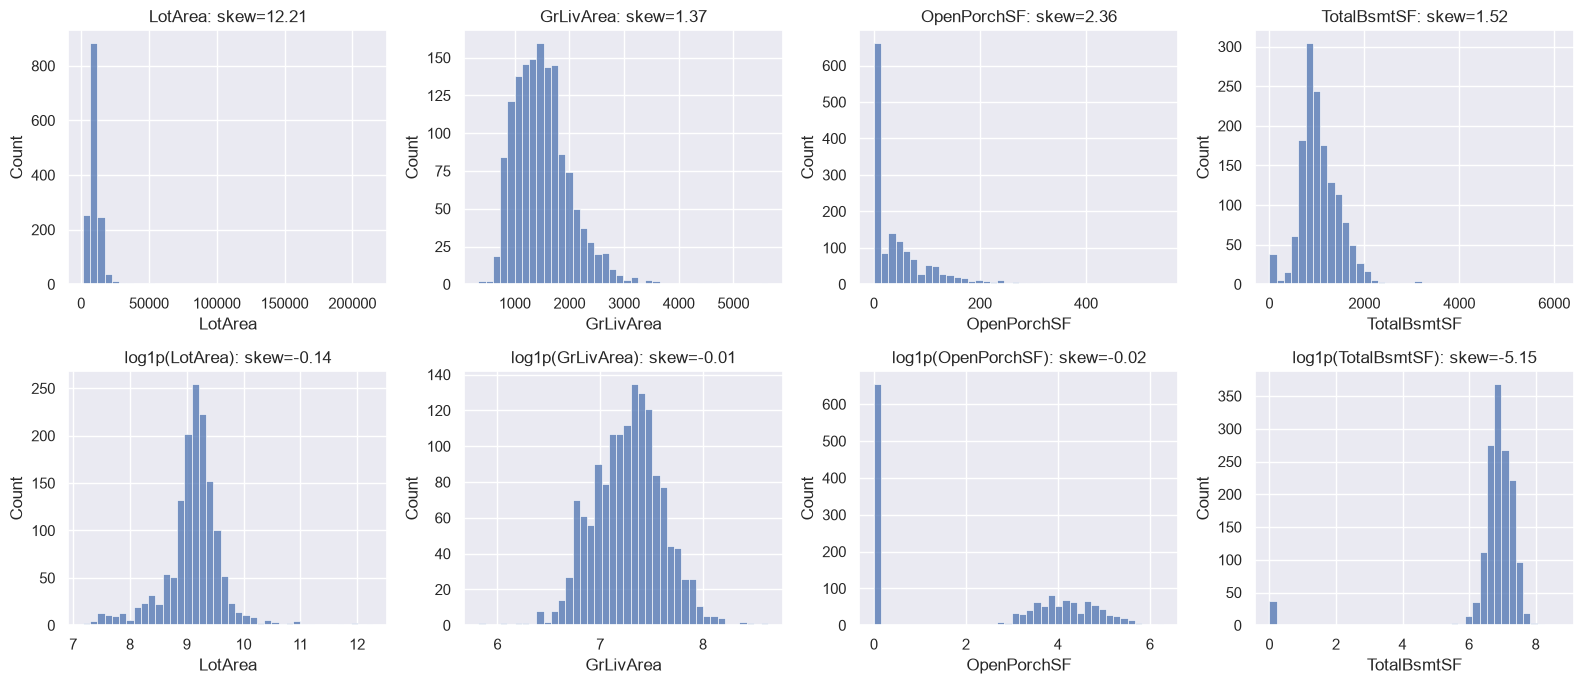

In [59]:
def plot_before_after_log1p(df: pd.DataFrame, columns: list[str]) -> None:
    """Рисует для каждой колонки гистограмму до log1p в верхнем ряду и после в нижнем"""
    fig, axes = plt.subplots(2, len(columns), figsize=(4 * len(columns), 7))
    for position, column in enumerate(columns):
        logged = np.log1p(df[column])
        sns.histplot(df[column], bins=40, ax=axes[0, position])
        axes[0, position].set_title(f"{column}: skew={df[column].skew():.2f}")
        sns.histplot(logged, bins=40, ax=axes[1, position])
        axes[1, position].set_title(f"log1p({column}): skew={logged.skew():.2f}")
    plt.tight_layout()
    plt.show()


plot_before_after_log1p(train, ["LotArea", "GrLivArea", "OpenPorchSF", "TotalBsmtSF"])

### Выводы по скошенности

- Скошенных колонок 20 из 35. Самые скошенные `MiscVal` 24.5, `PoolArea` 14.8, `LotArea` 12.2, `3SsnPorch` 10.3, `LowQualFinSF` 9.0. Кроме `LotArea`, это почти целиком нули с редкими большими значениями, доля нулей у них от 0.96 до 1.0
- Для непрерывных признаков площади `log1p` работает хорошо и усиливает связь с ценой. У `LotArea` скошенность падает с 12.21 до минус 0.14, а корреляция с ценой растёт с 0.26 до 0.40. У `OpenPorchSF` скошенность с 2.36 до минус 0.02, корреляция с 0.32 до 0.46. У `GrLivArea` корреляция растёт с 0.70 до 0.73. Гипотеза про логарифм `LotArea` и `OpenPorchSF` подтвердилась
- Для колонок с нулями логарифм подходит хуже. У `TotalBsmtSF` около 3% домов с нулевой площадью, то есть без подвала, после `log1p` они превращаются в далёкую левую полку, скошенность становится минус 5.15, а корреляция с ценой падает с 0.61 до 0.37. Так же теряют `BsmtFinSF1` с 0.37 до 0.21 и `2ndFlrSF` с 0.32 до 0.18. Для таких признаков логарифм нельзя применять вслепую
- У `OpenPorchSF` после логарифма скошенность около нуля, но гистограмма показывает, что причина в двух группах: огромный пик нулей, доля нулей 0.45, и почти симметричный колокол у остальных. Сама по себе скошенность тут вводит в заблуждение, полезно смотреть и на график
- Признаки, которые почти целиком состоят из нулей, `MiscVal`, `PoolArea`, `3SsnPorch`, `LowQualFinSF`, остаются скошенными и после логарифма, ему нечего выпрямлять
- Гипотезы для проверки в следующих ноутбуках: `log1p` для непрерывных площадей `LotArea`, `GrLivArea`, `1stFlrSF`, `OpenPorchSF`, `WoodDeckSF` улучшит линейные модели, а для признаков с большой долей нулей лучше отдельный флаг наличия плюс логарифм положительной части или вообще без преобразования. Деревьям и бустингам преобразование не нужно, они не чувствительны к монотонным преобразованиям

### Выбросы

Выброс, который вредит модели, это не просто большое значение, а дом, который нарушает общую связь признака с ценой, например огромная площадь при низкой цене. Такие точки тянут линию регрессии к себе и портят метрику, особенно на логарифме цены

Сначала посмотрим на диаграммы рассеяния главных признаков площади против `log1p(SalePrice)`. Точки со статусом продажи `SaleCondition == Partial` выделим цветом: по описанию данных это дома, которые не были достроены на момент оценки, и цена у них может не соответствовать площади

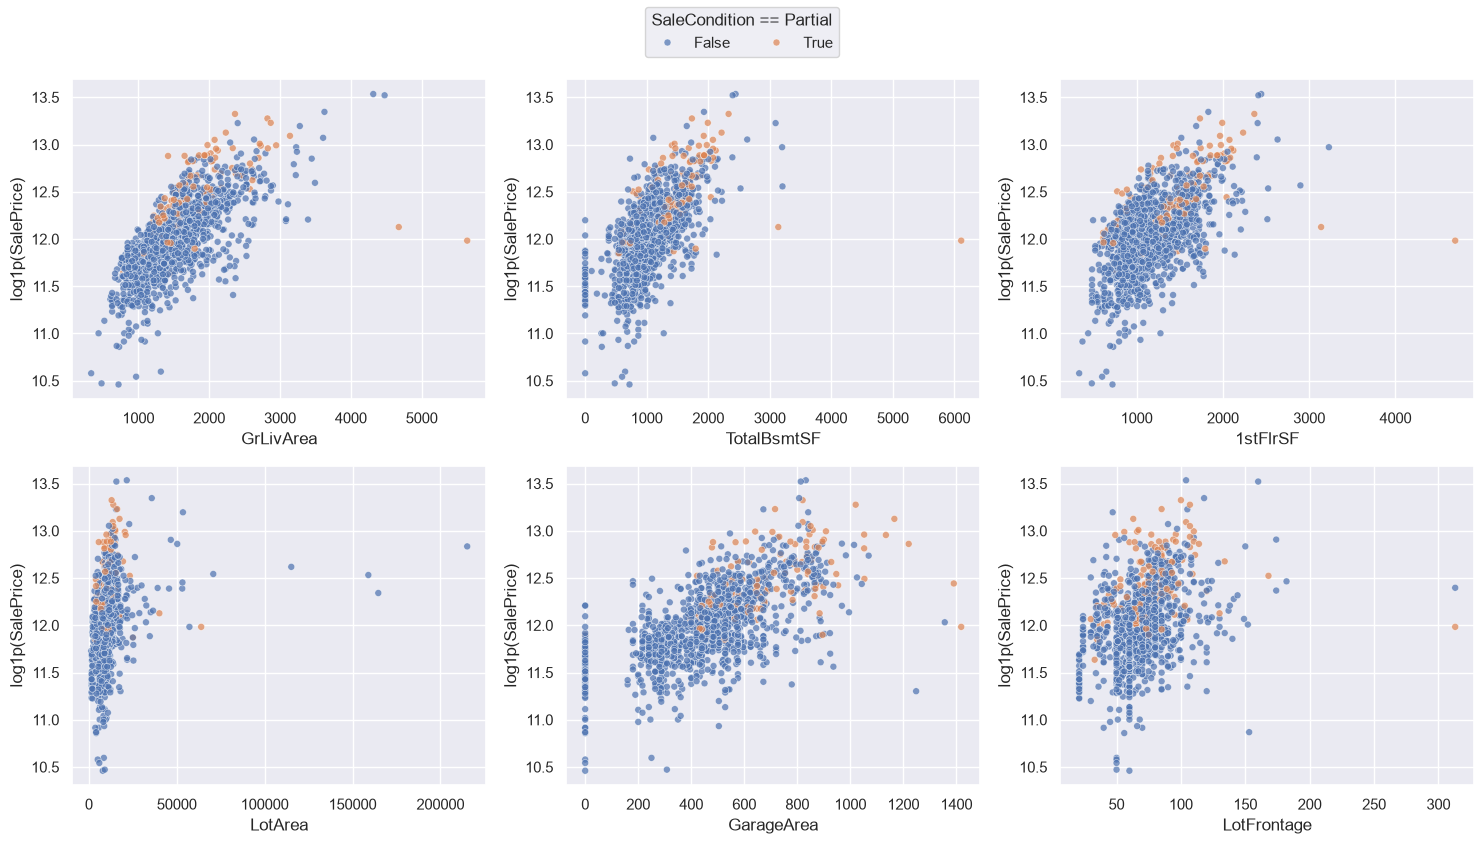

In [60]:
def plot_price_scatter(df: pd.DataFrame, columns: list[str], target: pd.Series, highlight: pd.Series) -> None:
    """Рисует диаграммы рассеяния признаков против таргета в сетке 2 на 3.

    Точки, для которых highlight истинно, выделяются цветом. Общая легенда
    выносится над графиками, чтобы не закрывать точки
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
    for axis, column in zip(axes.ravel(), columns):
        sns.scatterplot(x=df[column], y=target, hue=highlight, alpha=0.7, s=25, ax=axis)
        axis.set_ylabel("log1p(SalePrice)")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    for axis in axes.ravel():
        axis.get_legend().remove()
    fig.legend(handles, labels, title=highlight.name, loc="upper center", ncol=2)
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    plt.show()


is_partial = (train["SaleCondition"] == "Partial").rename("SaleCondition == Partial")
plot_price_scatter(
    train, ["GrLivArea", "TotalBsmtSF", "1stFlrSF", "LotArea", "GarageArea", "LotFrontage"], log_target, is_partial
)

На графике `GrLivArea` справа внизу видны точки с огромной жилой площадью и относительно низкой ценой. Выведем все дома с `GrLivArea` больше 4000 в train и в test

In [61]:
LARGE_AREA = 4000
suspect_columns = ["Id", "GrLivArea", "TotalBsmtSF", "LotArea", "OverallQual", "SaleCondition", "SaleType", TARGET]

pd.concat(
    {
        "train": train.loc[train["GrLivArea"] > LARGE_AREA, suspect_columns],
        "test": test.loc[test["GrLivArea"] > LARGE_AREA, suspect_columns[:-1]],
    }
)

Id  GrLivArea  TotalBsmtSF  LotArea  OverallQual SaleCondition  \
train 523    524       4676       3138.0    40094           10       Partial   
      691    692       4316       2444.0    21535           10        Normal   
      1182  1183       4476       2396.0    15623           10       Abnorml   
      1298  1299       5642       6110.0    63887           10       Partial   
test  1089  2550       5095       5095.0    39290           10       Partial   

           SaleType  SalePrice  
train 523       New   184750.0  
      691        WD   755000.0  
      1182       WD   745000.0  
      1298      New   160000.0  
test  1089      New        NaN

Чтобы понять, можно ли искать выбросы автоматически, посчитаем для каждого числового признака, сколько значений выходит за пределы правила межквартильного размаха

In [62]:
def iqr_outlier_counts(df: pd.DataFrame, columns: list[str], factor: float = 1.5) -> pd.DataFrame:
    """Считает для каждой колонки число значений за пределами усов по правилу IQR.

    Значение считается выбросом, если оно ниже Q1 минус factor * IQR или выше
    Q3 плюс factor * IQR. Возвращает число выбросов и их долю от всех строк
    """
    q1 = df[columns].quantile(0.25)
    q3 = df[columns].quantile(0.75)
    iqr = q3 - q1
    is_outlier = (df[columns] < q1 - factor * iqr) | (df[columns] > q3 + factor * iqr)
    counts = is_outlier.sum()
    result = pd.DataFrame({"outlier_count": counts, "outlier_share": (counts / len(df)).round(3)})
    return result.sort_values("outlier_count", ascending=False)


iqr_outlier_counts(train, NUMERIC_COLUMNS).head(10)

,outlier_count,outlier_share
EnclosedPorch,208,0.142
BsmtFinSF2,167,0.114
OverallCond,125,0.086
ScreenPorch,116,0.079
MasVnrArea,96,0.066
LotFrontage,88,0.060
BsmtHalfBath,82,0.056
OpenPorchSF,77,0.053
LotArea,69,0.047
KitchenAbvGr,68,0.047


### Выводы по выбросам

- Явных вредных выбросов два: дома с `Id` 524 и 1299. У них огромная жилая площадь, 4676 и 5642, максимальное качество `OverallQual` 10, но цена всего 184750 и 160000. На графике `GrLivArea` эти точки лежат далеко справа и сильно ниже общего тренда, на `TotalBsmtSF` и `1stFlrSF` видна та же картина. Оба дома проданы со статусом `Partial` и типом `New`, то есть это новостройки, которые не были достроены на момент оценки, и цена может не отражать заявленную площадь
- Два других дома с площадью больше 4000, `Id` 692 и 1183, стоят 755 и 745 тысяч и лежат на общем тренде. Это настоящие дорогие дома, поэтому удалять выбросы просто по порогу площади нельзя, нужно смотреть на цену
- Дома со статусом `Partial` на большинстве графиков лежат выше основной массы при той же площади. Гипотеза: `SaleCondition` полезный признак, а недостроенные новостройки ведут себя иначе, чем обычные продажи
- Правило межквартильного размаха для автоматического поиска выбросов не подходит: оно помечает выбросами 14.2% домов по `EnclosedPorch`, 11.4% по `BsmtFinSF2` и 8.6% по `OverallCond`. Это признаки с большим числом нулей или дискретные оценки, для них большие значения это не ошибки
- В test есть один дом с похожим профилем: `Id` 2550, площадь 5095, качество 10, `Partial` и `New`. Удалить его нельзя, поэтому модель должна уметь предсказывать такие дома, и это ещё один довод сравнить модели с удалением выбросов из train и без
- Гипотеза для проверки в следующем ноутбуке: удаление из train двух домов с `Id` 524 и 1299 снизит RMSE в кросс-валидации, особенно у линейных моделей

## 4. Категориальные признаки

К категориальным относим все текстовые колонки и `MSSubClass`, которая по описанию данных является кодом категории. Пропуск в этом разделе считаем отдельной категорией с меткой `NA`, потому что, как выяснили выше, в большинстве колонок он означает отсутствие объекта

### Число категорий

Главный вопрос здесь про one-hot кодирование: если превратить каждую категорию в отдельную колонку, признаков станет намного больше. Посчитаем, сколько категорий в каждой колонке и сколько среди них редких, с долей меньше 1% от всех домов

In [63]:
CATEGORICAL_COLUMNS = train.select_dtypes(exclude="number").columns.tolist() + ["MSSubClass"]


def na_as_category(series: pd.Series) -> pd.Series:
    """Заменяет пропуски в колонке на категорию NA"""
    return series.astype(object).fillna("NA")


def category_summary(df: pd.DataFrame, columns: list[str], rare_threshold: float = 0.01) -> pd.DataFrame:
    """Считает число категорий, долю самой частой и число редких категорий в каждой колонке.

    Пропуск считается отдельной категорией с меткой NA. Редкой называется
    категория, доля которой меньше rare_threshold
    """
    rows = {}
    for column in columns:
        shares = na_as_category(df[column]).value_counts(normalize=True)
        rows[column] = {
            "n_categories": len(shares),
            "top_share": shares.iloc[0],
            "n_rare": (shares < rare_threshold).sum(),
        }
    return pd.DataFrame.from_dict(rows, orient="index").sort_values("n_categories", ascending=False)


category_stats = category_summary(train, CATEGORICAL_COLUMNS)
print(
    f"категориальных колонок: {len(CATEGORICAL_COLUMNS)}, "
    f"one-hot даст {category_stats['n_categories'].sum()} колонок, "
    f"из них редких категорий {category_stats['n_rare'].sum()}"
)
category_stats.round(3)

категориальных колонок: 44, one-hot даст 282 колонок, из них редких категорий 89


,n_categories,top_share,n_rare
Neighborhood,25,0.154,3
Exterior2nd,16,0.345,6
Exterior1st,15,0.353,5
MSSubClass,15,0.367,3
SaleType,9,0.868,6
Condition1,9,0.863,4
HouseStyle,8,0.497,3
RoofMatl,8,0.982,7
Condition2,8,0.990,7
BsmtFinType1,7,0.295,0


### Категории в train и в test

Для one-hot важно, чтобы наборы категорий в train и test совпадали. Если в test встретится категория, которой не было в train, для неё не будет колонки, а если категория есть только в train, колонка останется пустой. Найдём колонки, где наборы различаются. Пропуск здесь тоже считается категорией `NA`, так что `NA` только в test означает настоящие пропуски, которых нет в train

In [64]:
def category_mismatch(train_df: pd.DataFrame, test_df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Находит категории, которые есть только в одной из выборок.

    Пропуск считается категорией NA. Возвращает таблицу только по тем колонкам,
    где наборы категорий в train и test различаются
    """
    rows = {}
    for column in columns:
        train_levels = set(na_as_category(train_df[column]))
        test_levels = set(na_as_category(test_df[column]))
        if train_levels != test_levels:
            rows[column] = {
                "only_train": sorted(train_levels - test_levels, key=str),
                "only_test": sorted(test_levels - train_levels, key=str),
            }
    return pd.DataFrame.from_dict(rows, orient="index")


mismatch = category_mismatch(train, test, CATEGORICAL_COLUMNS)
print(f"колонок с различающимися наборами категорий: {len(mismatch)} из {len(CATEGORICAL_COLUMNS)}")
mismatch

колонок с различающимися наборами категорий: 16 из 44


,only_train,only_test
MSZoning,[],[NA]
Utilities,[NoSeWa],[NA]
Condition2,"[RRAe, RRAn, RRNn]",[]
HouseStyle,[2.5Fin],[]
RoofMatl,"[ClyTile, Membran, Metal, Roll]",[]
Exterior1st,"[ImStucc, Stone]",[NA]
Exterior2nd,[Other],[NA]
Heating,"[Floor, OthW]",[]
Electrical,"[Mix, NA]",[]
KitchenQual,[],[NA]


Категории, которых нет в train, для нас опаснее, чем категории только в train, поэтому посчитаем, сколько домов в test содержат хотя бы одну такую категорию

In [65]:
unseen = pd.DataFrame(
    {
        column: ~na_as_category(test[column]).isin(set(na_as_category(train[column])))
        for column in CATEGORICAL_COLUMNS
    }
)
unseen_per_column = unseen.sum()
print(f"домов в test с категорией, которой нет в train: {unseen.any(axis=1).sum()} из {len(test)}")
unseen_per_column[unseen_per_column > 0]

домов в test с категорией, которой нет в train: 10 из 1459


MSZoning       4
Utilities      2
Exterior1st    1
Exterior2nd    1
KitchenQual    1
Functional     2
SaleType       1
MSSubClass     1
dtype: int64

### Выводы по числу категорий

- Категориальных колонок 44 из 79 признаков. Полный one-hot даст 282 колонки, из них 89 приходится на редкие категории с долей меньше 1%, то есть почти треть. Признаков станет заметно больше, но не катастрофически: 282 колонки на 1460 домов
- Больше всего категорий у `Neighborhood` 25, `Exterior2nd` 16, `Exterior1st` 15 и `MSSubClass` 15. Эти четыре колонки дают 71 из 282 колонок
- Хуже всего с редкими категориями у почти константных колонок: у `RoofMatl` и `Condition2` из 8 категорий редкими являются 7. Такие колонки почти ничего не добавляют модели, но раздувают one-hot
- Набор категорий отличается между train и test у 16 колонок из 44. В `RoofMatl`, `Condition2`, `Heating` и ещё нескольких колонках часть категорий есть только в train, это безвредно: колонка для такой категории останется в test пустой
- Категории только в test это в основном `NA` в `MSZoning`, `Utilities`, `Exterior1st`, `Exterior2nd`, `KitchenQual`, `Functional` и `SaleType`. Это настоящие пропуски из таблицы пропусков выше, в train их нет, значит их нужно заполнить до кодирования, используя статистику train
- Одна настоящая новая категория: код `150` в `MSSubClass` есть в test и отсутствует в train. Всего домов в test с категорией, которой нет в train, 10 из 1459
- Гипотезы для проверки в следующих ноутбуках: объединение редких категорий уменьшит число колонок без потери качества, а one-hot должен игнорировать неизвестные категории, чтобы не падать на test. Как закодировать признаки с упорядоченными оценками качества, разберём дальше

### Связь категориальных признаков с ценой

Для числовых признаков мы использовали корреляцию, а для категориальных она не подходит. Вместо неё посчитаем долю разброса `log1p(SalePrice)`, которую объясняет колонка. Для каждой колонки берём отношение межгрупповой суммы квадратов к общей: ноль значит, что категории вообще не различают цену, единица значит, что внутри каждой категории цена одинаковая. Пропуск считаем отдельной категорией `NA`

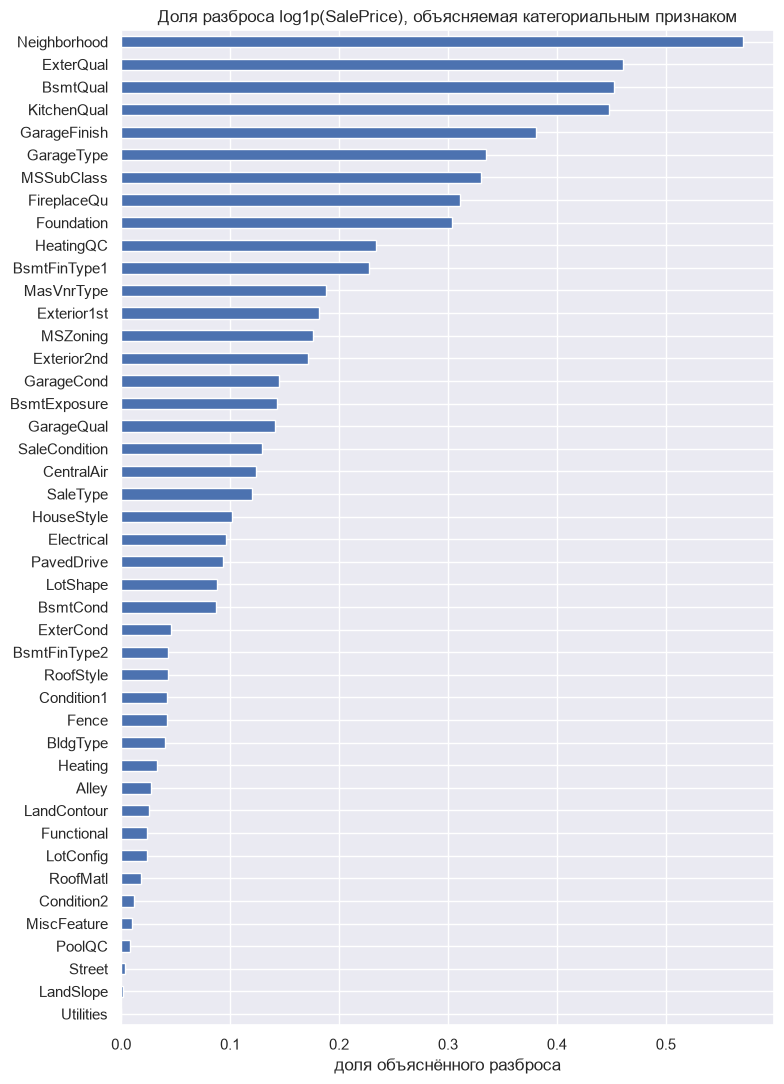

In [66]:
def category_price_strength(df: pd.DataFrame, columns: list[str], target: pd.Series) -> pd.Series:
    """Считает, какую долю разброса таргета объясняет каждая категориальная колонка.

    Это отношение межгрупповой суммы квадратов к общей. Значение 0 означает,
    что категории не различают таргет, значение 1 означает, что внутри каждой
    категории таргет постоянен. Пропуск считается категорией NA
    """
    total = ((target - target.mean()) ** 2).sum()
    strength = {}
    for column in columns:
        groups = target.groupby(na_as_category(df[column])).agg(["count", "mean"])
        between = (groups["count"] * (groups["mean"] - target.mean()) ** 2).sum()
        strength[column] = between / total
    return pd.Series(strength).sort_values(ascending=False)


category_strength = category_price_strength(train, CATEGORICAL_COLUMNS, log_target)
category_strength.iloc[::-1].plot.barh(figsize=(8, 11))
plt.title("Доля разброса log1p(SalePrice), объясняемая категориальным признаком")
plt.xlabel("доля объяснённого разброса")
plt.tight_layout()
plt.show()

Те же значения в виде таблицы, чтобы видеть точные числа

In [67]:
category_strength.to_frame("explained_share").style.background_gradient(cmap="Blues", vmin=0, vmax=1).format("{:.2f}")

,explained_share
Neighborhood,0.57
ExterQual,0.46
BsmtQual,0.45
KitchenQual,0.45
GarageFinish,0.38
GarageType,0.33
MSSubClass,0.33
FireplaceQu,0.31
Foundation,0.30
HeatingQC,0.23


Посмотрим на разброс цены внутри категорий для нескольких номинальных признаков, у которых нет естественного порядка. Категории на каждом графике отсортированы по медианной цене

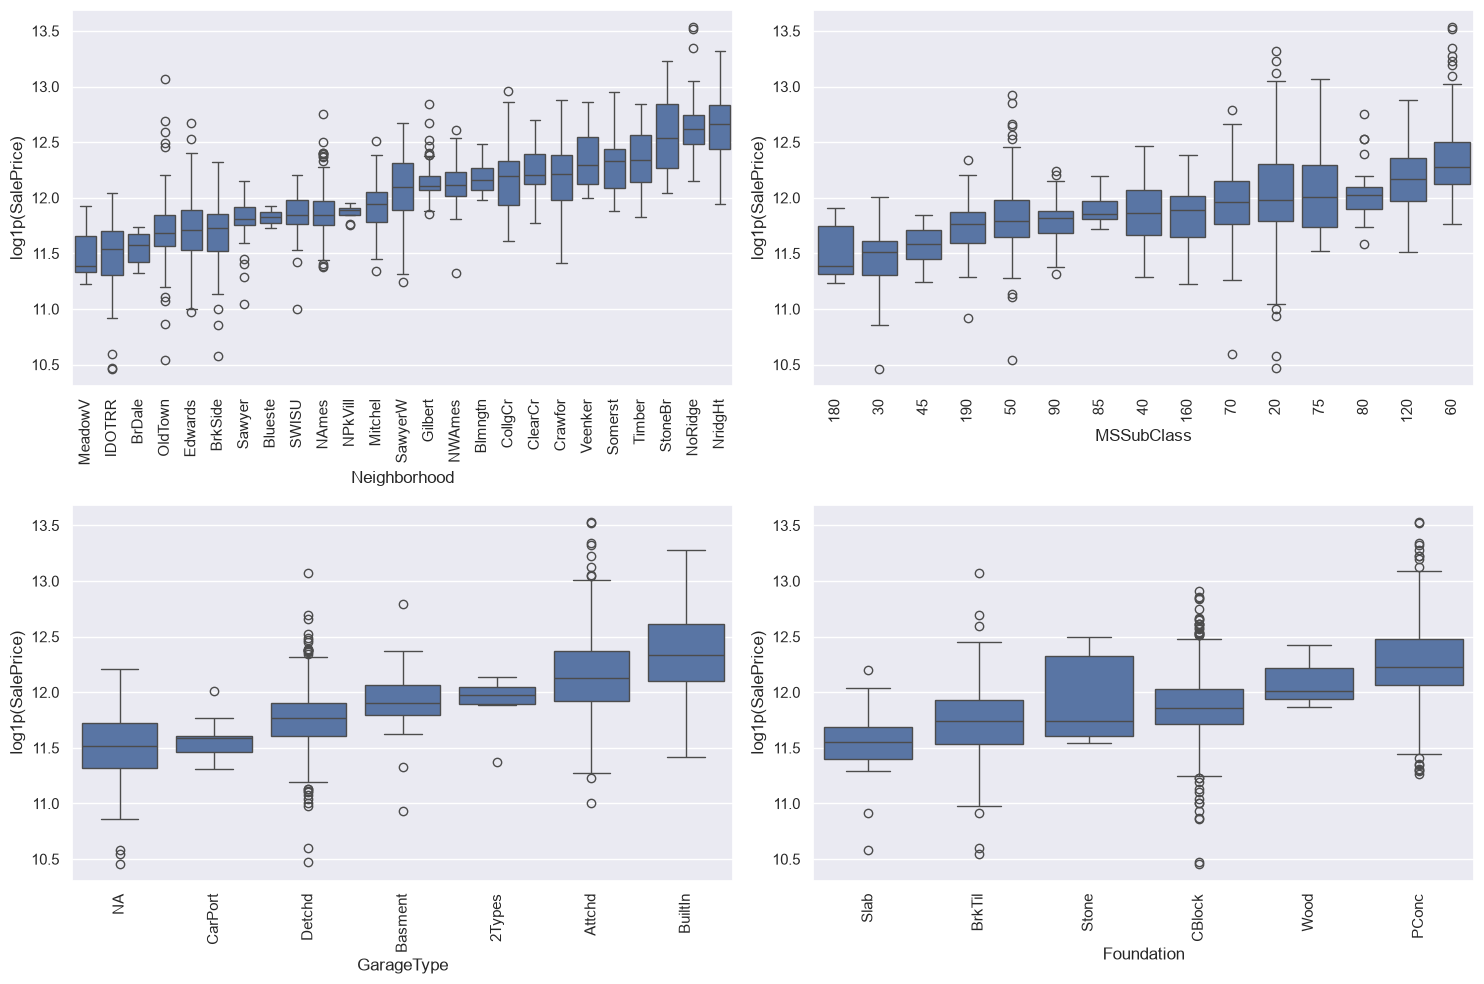

In [68]:
def plot_price_by_category(df: pd.DataFrame, columns: list[str], target: pd.Series) -> None:
    """Рисует в сетке 2 на 2 боксплот таргета для каждой категории колонки.

    Категории сортируются по медиане таргета. Пропуск считается категорией NA,
    числовые коды категорий приводятся к строкам
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    for axis, column in zip(axes.ravel(), columns):
        data = pd.DataFrame({column: na_as_category(df[column]).astype(str), "log_price": target})
        order = data.groupby(column)["log_price"].median().sort_values().index
        sns.boxplot(data=data, x=column, y="log_price", order=order, ax=axis)
        axis.set_ylabel("log1p(SalePrice)")
        axis.tick_params(axis="x", rotation=90)
    plt.tight_layout()
    plt.show()


plot_price_by_category(train, ["Neighborhood", "MSSubClass", "GarageType", "Foundation"], log_target)

### Выводы по связи категориальных признаков с ценой

- Сильнее всего цену объясняет `Neighborhood`, около 0.57 разброса. Дальше идут оценки качества внешней отделки, подвала и кухни `ExterQual`, `BsmtQual`, `KitchenQual`, около 0.45 каждая, затем `GarageFinish` 0.38, `GarageType` и `MSSubClass` по 0.33. Район и качество отделки главные категориальные признаки
- Практически ничего не объясняют `Utilities`, `Street`, `LandSlope`, а также `RoofMatl`, `Condition2`, `MiscFeature`, `PoolQC`, у которых объяснённая доля не выше 0.02. Почти все они уже попали в список почти константных признаков, что подтверждает кандидатов на удаление или объединение редких категорий
- На графике видно, что медианная цена в зависимости от района растёт примерно от 11.4 и 11.5 в `MeadowV` и `IDOTRR` до около 12.6 в `NridgHt`, `NoRidge` и `StoneBr`. Внутри отдельных районов, например `OldTown` и `Edwards`, разброс большой и много выбросов вверх, то есть район не единственный фактор
- У `GarageType` самая высокая медиана у `BuiltIn`, самые низкие у домов без гаража `NA` и у `CarPort`. У `Foundation` выше всех `PConc`, ниже всех `Slab`. Порядок категорий на графиках устойчивый, а значит у номинальных признаков есть скрытая упорядоченность по цене
- Гипотеза для проверки в следующих ноутбуках: для `Neighborhood` с 25 категориями target encoding, посчитанный внутри фолдов кросс-валидации, даст лучший результат, чем one-hot, потому что не раздувает число колонок, а порядок районов по цене выражен чётко

### Шкалы качества

Большая группа колонок использует одну и ту же шкалу оценок: `Po`, `Fa`, `TA`, `Gd`, `Ex` от худшего к лучшему, а `NA` означает отсутствие объекта. Если цена растёт вдоль этой шкалы, такие колонки можно закодировать числами по порядку вместо one-hot, это экономит колонки и сохраняет порядок. Проверим это: посчитаем медианную цену для каждого уровня шкалы и посмотрим, растёт ли она

In [69]:
QUALITY_COLUMNS = [
    "ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC",
    "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC",
]
QUALITY_LEVELS = ["NA", "Po", "Fa", "TA", "Gd", "Ex"]


def median_price_by_level(df: pd.DataFrame, columns: list[str], levels: list[str], target_column: str) -> pd.DataFrame:
    """Считает медианную цену для каждого уровня шкалы качества в каждой колонке.

    Пропуск считается уровнем NA. Если какого-то уровня в колонке нет, в таблице
    стоит пропуск. Столбец increasing показывает, растёт ли медианная цена вдоль
    шкалы от Po до Ex среди имеющихся уровней, уровень NA в проверке не участвует
    """
    prices = {
        column: df.groupby(na_as_category(df[column]))[target_column].median() for column in columns
    }
    table = pd.DataFrame(prices).T.reindex(columns=levels)
    scale = table.drop(columns="NA")
    table["increasing"] = scale.apply(lambda row: row.dropna().is_monotonic_increasing, axis=1)
    return table


median_price_by_level(train, QUALITY_COLUMNS, QUALITY_LEVELS, TARGET)

,NA,Po,Fa,TA,Gd,Ex,increasing
ExterQual,NaN,NaN,82250.0,139450.0,220000.0,364606.5,True
ExterCond,NaN,76500.0,95750.0,167370.0,151250.0,161000.0,False
BsmtQual,101800.0,NaN,112000.0,135500.0,192070.0,318000.0,True
BsmtCond,101800.0,64000.0,118500.0,165000.0,193879.0,NaN,True
HeatingQC,NaN,87000.0,123500.0,135000.0,152000.0,194700.0,True
KitchenQual,NaN,NaN,115000.0,137000.0,201400.0,316750.0,True
FireplaceQu,135000.0,131500.0,158000.0,187500.0,206950.0,314250.0,True
GarageQual,100000.0,96500.0,115000.0,170000.0,209115.0,127500.0,False
GarageCond,100000.0,108000.0,114504.0,170000.0,148000.0,124000.0,False
PoolQC,162900.0,NaN,215500.0,NaN,171000.0,490000.0,False


Чтобы понимать, насколько надёжны эти медианы, посмотрим, сколько домов приходится на каждый уровень

In [70]:
quality_counts = pd.DataFrame(
    {column: na_as_category(train[column]).value_counts() for column in QUALITY_COLUMNS}
).T.reindex(columns=QUALITY_LEVELS)
quality_counts.fillna(0).astype(int)

,NA,Po,Fa,TA,Gd,Ex
ExterQual,0,0,14,906,488,52
ExterCond,0,1,28,1282,146,3
BsmtQual,37,0,35,649,618,121
BsmtCond,37,2,45,1311,65,0
HeatingQC,0,1,49,428,241,741
KitchenQual,0,0,39,735,586,100
FireplaceQu,690,20,33,313,380,24
GarageQual,81,3,48,1311,14,3
GarageCond,81,7,35,1326,9,2
PoolQC,1453,0,2,0,3,2


### Выводы по шкалам качества

- Медианная цена строго растёт вдоль шкалы от `Po` до `Ex` у шести колонок: `ExterQual`, `BsmtQual`, `BsmtCond`, `HeatingQC`, `KitchenQual`, `FireplaceQu`. Для них порядковое кодирование числами оправдано
- Порядок нарушается у `ExterCond`, `GarageQual`, `GarageCond` и `PoolQC`. У `GarageQual` уровни `Gd` и `Ex` встречаются у 14 и 3 домов, у `GarageCond` у 9 и 2 домов, а в `PoolQC` всего 7 домов с бассейном, поэтому медианы в этих группах ненадёжны. У `ExterCond` группы большие, и порядок нарушается по-настоящему: `Gd` у 146 домов, но их медианная цена ниже, чем у 1282 домов с `TA`
- Оценки состояния `ExterCond`, `GarageCond`, `GarageQual` почти целиком состоят из уровня `TA`, поэтому дополнительно различают мало домов. Это согласуется с их невысокой объяснённой долей в предыдущем блоке, у `ExterCond` она всего около 0.04
- Отсутствие объекта `NA` у `BsmtQual`, `BsmtCond`, `GarageQual` и `GarageCond` дешевле уровня `Fa`, а у `FireplaceQu` находится между `Po` и `Fa`. Значит шкалу можно продолжить нулём для `NA`, порядок цены в основном сохранится. Исключение `PoolQC`, где `NA` дороже `Gd`, но там всего 7 домов с бассейном
- Гипотезы для проверки в следующих ноутбуках: порядковое кодирование от 0 до 5 для `ExterQual`, `BsmtQual`, `BsmtCond`, `HeatingQC`, `KitchenQual`, `FireplaceQu` даст не хуже, чем one-hot, при меньшем числе колонок. Для `ExterCond`, `GarageQual`, `GarageCond`, `PoolQC` порядковое кодирование ненадёжно, лучше объединить редкие уровни с `TA` или закодировать бинарным признаком

## 5. Признаки времени

В данных есть четыре колонки с датами: год постройки `YearBuilt`, год последней реконструкции `YearRemodAdd`, год и месяц продажи `YrSold` и `MoSold`. Проверим две гипотезы из заметок: возраст дома на момент продажи полезнее самого года постройки, а флаг того, что дом реконструировали, несёт отдельный сигнал

### Год реконструкции

По описанию данных `YearRemodAdd` совпадает с годом постройки, если реконструкции не было. Сначала проверим, так ли это на самом деле

In [71]:
n_same_year = (train["YearRemodAdd"] == train["YearBuilt"]).sum()
built_before_1950 = train["YearBuilt"] < 1950
remod_1950 = train["YearRemodAdd"] == 1950

print(f"минимальный YearRemodAdd в train: {train['YearRemodAdd'].min()}")
print(f"домов с YearRemodAdd равным YearBuilt: {n_same_year} из {len(train)}")
print(f"домов с YearRemodAdd равным 1950: {remod_1950.sum()}, максимальный YearBuilt среди них {train.loc[remod_1950, 'YearBuilt'].max()}")
print(f"среди {built_before_1950.sum()} домов, построенных до 1950, у {remod_1950[built_before_1950].mean():.0%} YearRemodAdd равен 1950")

минимальный YearRemodAdd в train: 1950
домов с YearRemodAdd равным YearBuilt: 764 из 1460
домов с YearRemodAdd равным 1950: 178, максимальный YearBuilt среди них 1950
среди 318 домов, построенных до 1950, у 52% YearRemodAdd равен 1950


Значение 1950 в `YearRemodAdd` выглядит как нижняя граница, которую ставили для старых домов вместо настоящего года. Тогда простой флаг `YearRemodAdd != YearBuilt` ошибочно пометит эти дома как реконструированные. Сравним простой флаг с флагом, который дополнительно требует год реконструкции позже 1950

In [72]:
def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    """Добавляет признаки времени: возраст дома, годы с реконструкции и флаг реконструкции.

    Флаг IsRemodeled истинен, если год реконструкции позже года постройки и позже 1950,
    потому что 1950 в YearRemodAdd стоит у старых домов как значение по умолчанию
    """
    result = df.copy()
    result["HouseAge"] = result["YrSold"] - result["YearBuilt"]
    result["YearsSinceRemod"] = result["YrSold"] - result["YearRemodAdd"]
    result["IsRemodeled"] = (result["YearRemodAdd"] > result["YearBuilt"]) & (result["YearRemodAdd"] > 1950)
    return result


train_time = add_time_features(train)
train_time["NaiveRemodeled"] = train_time["YearRemodAdd"] != train_time["YearBuilt"]

pd.DataFrame(
    {
        flag: train_time.groupby(flag)[TARGET].agg(["count", "median"]).stack()
        for flag in ["NaiveRemodeled", "IsRemodeled"]
    }
).T

False            True           
                count    median  count    median
NaiveRemodeled  764.0  170000.0  696.0  155000.0
IsRemodeled     930.0  156750.0  530.0  173000.0

### Возраст дома

Сравним связь с логарифмом цены у года постройки и возраста на момент продажи, а также у года реконструкции и числа лет с реконструкции

In [73]:
time_columns = ["YearBuilt", "HouseAge", "YearRemodAdd", "YearsSinceRemod"]
train_time[time_columns].corrwith(log_target).to_frame("corr_with_log_price").round(3)

,corr_with_log_price
YearBuilt,0.587
HouseAge,-0.587
YearRemodAdd,0.566
YearsSinceRemod,-0.568


Посмотрим на медианную цену по возрастным группам отдельно для домов без реконструкции и с ней

In [74]:
age_group = pd.cut(train_time["HouseAge"], bins=[-1, 10, 30, 60, 140])
train_time.groupby([age_group, "IsRemodeled"], observed=True)[TARGET].agg(["count", "median"])

count    median
HouseAge  IsRemodeled                 
(-1, 10]  False          285  213500.0
          True           149  239000.0
(10, 30]  False          124  186000.0
          True            84  203250.0
(30, 60]  False          372  136000.0
          True           154  150250.0
(60, 140] False          149  115000.0
          True           143  132000.0

### Год и месяц продажи

В обеих выборках даты продажи лежат в одном периоде, посмотрим на число продаж и цену по годам

In [75]:
pd.DataFrame(
    {
        "train_count": train.groupby("YrSold").size(),
        "test_count": test.groupby("YrSold").size(),
        "train_median_price": train.groupby("YrSold")[TARGET].median(),
    }
)

,train_count,test_count,train_median_price
YrSold,,,
2006,314,305,163995.0
2007,329,363,167000.0
2008,304,318,164000.0
2009,338,309,162000.0
2010,175,164,155000.0


In [76]:
pd.DataFrame(
    {
        "train_count": train.groupby("MoSold").size(),
        "train_median_price": train.groupby("MoSold")[TARGET].median(),
    }
).T

MoSold,1,2,3,4,5,6,7,8,9,10,11,12
train_count,58.0,52.0,106.0,141.0,204.0,253.0,234.0,122.0,63.0,89.0,79.0,59.0
train_median_price,151650.0,173250.0,165250.0,147000.0,154000.0,163000.0,165195.0,174450.0,185900.0,159000.0,173000.0,178000.0


In [77]:
train.pivot_table(index="YrSold", columns="MoSold", values=TARGET, aggfunc="count", fill_value=0)

MoSold,1,2,3,4,5,6,7,8,9,10,11,12
YrSold,,,,,,,,,,,,
2006,10,9,25,27,38,48,67,23,15,24,16,12
2007,13,8,23,23,43,59,51,40,11,16,24,18
2008,13,10,18,26,38,51,49,29,17,22,17,14
2009,12,10,19,26,37,59,61,30,20,27,22,15
2010,10,15,21,39,48,36,6,0,0,0,0,0


### Проверка дат на несоответствия

Проверим, нет ли домов, у которых даты противоречат друг другу: продажа или реконструкция раньше постройки, реконструкция позже года продажи, гараж построен позже продажи или раньше самого дома

In [78]:
DATE_RULES = {
    "продажа раньше постройки": lambda df: df["YrSold"] < df["YearBuilt"],
    "реконструкция раньше постройки": lambda df: df["YearRemodAdd"] < df["YearBuilt"],
    "реконструкция позже года продажи": lambda df: df["YearRemodAdd"] > df["YrSold"],
    "год гаража раньше постройки дома": lambda df: df["GarageYrBlt"] < df["YearBuilt"],
    "год гаража позже года продажи": lambda df: df["GarageYrBlt"] > df["YrSold"],
}


def date_inconsistencies(df: pd.DataFrame, rules: dict) -> pd.DataFrame:
    """Находит дома, у которых даты нарушают правила согласованности.

    Каждое правило это функция, которая возвращает булеву маску нарушающих домов.
    Для каждого правила возвращает число нарушающих домов и их Id
    """
    rows = {}
    for name, rule in rules.items():
        violators = df.loc[rule(df), "Id"]
        rows[name] = {"count": len(violators), "ids": violators.tolist()}
    return pd.DataFrame.from_dict(rows, orient="index")


pd.concat(
    {"train": date_inconsistencies(train, DATE_RULES), "test": date_inconsistencies(test, DATE_RULES)},
    axis=1,
)

train  \
                                 count   
продажа раньше постройки             0   
реконструкция раньше постройки       0   
реконструкция позже года продажи     1   
год гаража раньше постройки дома     9   
год гаража позже года продажи        0   

                                                                                   \
                                                                              ids   
продажа раньше постройки                                                       []   
реконструкция раньше постройки                                                 []   
реконструкция позже года продажи                                            [524]   
год гаража раньше постройки дома  [30, 94, 325, 601, 737, 1104, 1377, 1415, 1419]   
год гаража позже года продажи                                                  []   

                                  test  \
                                 count   
продажа раньше постройки             1   
реконструкция раньше постройки       1   
реконструкция позже года продажи     2   
год гаража раньше постройки дома     9   
год гаража позже года продажи        2   

                                                                                     
                                                                                ids  
продажа раньше постройки                                                     [2550]  
реконструкция раньше постройки                                               [1877]  
реконструкция позже года продажи                                       [2296, 2550]  
год гаража раньше постройки дома  [1522, 1577, 1806, 1841, 1896, 1898, 2123, 226...  
год гаража позже года продажи                                          [2550, 2593]

Посмотрим на дома из test, у которых продажа раньше постройки или год гаража позже продажи

In [79]:
date_columns = ["Id", "YearBuilt", "YearRemodAdd", "GarageYrBlt", "YrSold", "SaleCondition"]
test.loc[(test["YrSold"] < test["YearBuilt"]) | (test["GarageYrBlt"] > test["YrSold"]), date_columns]

,Id,YearBuilt,YearRemodAdd,GarageYrBlt,YrSold,SaleCondition
1089,2550,2008,2009,2008.0,2007,Partial
1132,2593,2006,2007,2207.0,2007,Partial


### Выводы по признакам времени

- Значение 1950 в `YearRemodAdd` это нижняя граница, а не настоящий год: минимум по train равен 1950, у 178 домов с этим значением максимальный год постройки тоже 1950, а среди 318 домов, построенных до 1950, у 52% год реконструкции равен 1950. Поэтому простой флаг `YearRemodAdd != YearBuilt` вводит в заблуждение: он помечает реконструированными 696 домов и показывает, что они дешевле, 155 тысяч против 170 тысяч
- Флаг `IsRemodeled` с дополнительным условием года реконструкции позже 1950 даёт 530 домов, и картина обратная: реконструированные дома дороже, 173 тысячи против 157 тысяч. Такие ловушки в данных легко пропустить, поэтому в признаке нужно явно учитывать значение 1950
- Внутри каждой возрастной группы реконструированные дома дороже нереконструированных: 239 тысяч против 214 тысяч в группе до 10 лет, 203 против 186 тысяч от 10 до 30 лет, 150 против 136 тысяч от 30 до 60 лет, 132 против 115 тысяч старше 60 лет. Значит флаг несёт сигнал сверх возраста. Гипотеза о флаге реконструкции подтвердилась
- Возраст дома `HouseAge` связан с ценой так же, как год постройки, только с обратным знаком: корреляция минус 0.587 против 0.587. То же у `YearsSinceRemod` и `YearRemodAdd`, минус 0.568 и 0.566. Причина в том, что все продажи приходятся на 2006 до 2010 годы, и возраст отличается от года постройки на почти одну и ту же величину. Гипотеза о том, что возраст полезнее года, не подтвердилась, для линейных моделей и деревьев это по сути один и тот же признак, достаточно оставить один из них
- Продажи в train и test приходятся на один период 2006 до 2010 годов и распределены по годам похоже. Медианная цена по годам почти не меняется, от 162 до 167 тысяч в 2006 до 2009 годах и 155 тысяч в 2010, причём данные за 2010 год заканчиваются в июле. Временного тренда, который можно использовать, нет, это согласуется с корреляциями `YrSold` и `MoSold` около нуля из блока про числовые признаки
- По месяцам заметна сезонность числа продаж: пик в июне и июле, 253 и 234 дома, против 58 и 52 домов в январе и феврале. Медианная цена по месяцам колеблется от 147 до 186 тысяч без ясной закономерности, при этом в отдельных месяцах мало домов
- Несоответствий дат мало. В train нет домов с продажей или реконструкцией раньше постройки, есть один дом с реконструкцией позже года продажи, `Id` 524, уже известный выброс. В test дом `Id` 2550, тот самый огромный `Partial` с площадью 5095, продан в 2007 году, а построен в 2008, и у него же реконструкция и гараж позже продажи. У дома `Id` 2593 год гаража равен 2207, это явная опечатка. Ещё в test один дом, `Id` 1877, имеет реконструкцию раньше постройки. Год гаража раньше года постройки дома у 9 домов в каждой выборке, это может быть настоящим, например старый гараж при перестроенном доме
- Практический вывод: у дома `Id` 2550 возраст `HouseAge` получится отрицательным, минус 1, а год гаража 2207 нужно исправить или обрезать, иначе признаки возраста будут содержать выбросы
- Гипотезы для проверки в следующих ноутбуках: добавить флаг `IsRemodeled` с учётом значения 1950, оставить один из признаков `YearBuilt` или `HouseAge`, а `YrSold` и `MoSold` проверить на удаление, потому что связи с ценой у них практически нет

## 6. Сравнение train и test

Кросс-валидация на train честно оценивает качество на test, только если выборки похожи. Проверим это двумя способами: сравним распределения числовых признаков по отдельности и попробуем обучить модель, которая отличает строки train от строк test

### Числовые признаки по отдельности

Сравниваем распределение каждого числового признака в train и test критерием Колмогорова Смирнова. Малое значение p говорит, что распределения различаются. Столбец `Id` исключаем: это просто порядковый номер, у train он идёт от 1 до 1460, у test дальше

In [80]:
def ks_comparison(train_df: pd.DataFrame, test_df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Сравнивает распределения колонок в train и test критерием Колмогорова Смирнова.

    Для каждой колонки возвращает статистику и p-value, пропуски игнорируются.
    Малое p-value означает, что распределения в выборках различаются
    """
    rows = {}
    for column in columns:
        result = stats.ks_2samp(train_df[column].dropna(), test_df[column].dropna())
        rows[column] = {"ks_statistic": result.statistic, "p_value": result.pvalue}
    return pd.DataFrame.from_dict(rows, orient="index").sort_values("p_value")


ks_results = ks_comparison(train, test, NUMERIC_COLUMNS)
print(f"колонок с p-value меньше 0.05: {(ks_results['p_value'] < 0.05).sum()} из {len(ks_results)}")
ks_results.head(8).round(3)

колонок с p-value меньше 0.05: 0 из 35


,ks_statistic,p_value
2ndFlrSF,0.047,0.074
GrLivArea,0.046,0.082
TotRmsAbvGrd,0.045,0.100
TotalBsmtSF,0.041,0.160
MoSold,0.038,0.241
LotArea,0.037,0.256
YearRemodAdd,0.037,0.258
BsmtUnfSF,0.030,0.502


### Отличима ли тестовая выборка от обучающей

Проверка по отдельным признакам не видит различий, которые возникают только в сочетании признаков. Поэтому обучим случайный лес предсказывать, из какой выборки пришла строка, по всем признакам, кроме `Id`. Качество меряем ROC AUC в кросс-валидации: значение около 0.5 означает, что модель не может отличить train от test, а значение около 1 означает, что выборки различаются

In [81]:
def adversarial_validation(
    train_df: pd.DataFrame, test_df: pd.DataFrame, columns: list[str], n_splits: int = 5, seed: int = 42
) -> tuple[pd.Series, pd.Series]:
    """Проверяет, можно ли по признакам отличить строки train от строк test.

    Обучает случайный лес предсказывать, из какой выборки строка. Возвращает
    ROC AUC по фолдам и важность признаков. AUC около 0.5 означает, что выборки
    неотличимы. Пропуски в категориях считаются категорией NA, пропуски в числах
    заполняются медианой
    """
    features = pd.concat([train_df[columns], test_df[columns]], ignore_index=True)
    for column in features.select_dtypes(exclude="number").columns:
        features[column] = na_as_category(features[column])
    features = pd.get_dummies(features)
    features = features.fillna(features.median())
    labels = np.r_[np.zeros(len(train_df)), np.ones(len(test_df))]

    model = RandomForestClassifier(n_estimators=200, min_samples_leaf=5, random_state=seed, n_jobs=-1)
    folds = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    scores = cross_val_score(model, features, labels, cv=folds, scoring="roc_auc")
    importances = pd.Series(model.fit(features, labels).feature_importances_, index=features.columns)
    return pd.Series(scores), importances.sort_values(ascending=False)


adversarial_scores, adversarial_importances = adversarial_validation(train, test, feature_columns)
print(f"ROC AUC по фолдам: {adversarial_scores.round(3).tolist()}, среднее {adversarial_scores.mean():.3f}")
adversarial_importances.head(6).round(3)

ROC AUC по фолдам: [0.516, 0.53, 0.487, 0.534, 0.502], среднее 0.514


LotArea        0.043
BsmtUnfSF      0.042
GrLivArea      0.041
TotalBsmtSF    0.039
1stFlrSF       0.039
GarageArea     0.037
dtype: float64

### Выводы по сравнению train и test

- Ни у одного из 35 числовых признаков распределения в train и test статистически не различаются, все p-value больше 0.05. Ближе всего к порогу `2ndFlrSF` с p-value 0.074 и `GrLivArea` с 0.082, но и это различие незначимое
- Случайный лес не смог отличить train от test: ROC AUC по фолдам от 0.487 до 0.534, в среднем 0.514, то есть почти как случайное угадывание. Важность признаков плоская, у шести самых важных от 0.037 до 0.043, ни один признак не выделяется. Высокая важность у непрерывных площадей здесь объясняется тем, что по ним у леса больше всего точек разбиения, а не различием выборок
- Выборки выглядят как случайное разбиение одного и того же набора домов. Поэтому почти равные размеры, 1460 и 1459, это не проблема: кросс-валидация на train должна давать оценку, близкую к скору на test
- Небольшие различия всё же есть, но они не видны в агрегированных проверках: настоящие пропуски и категории, которых нет в train, у 10 домов test, о которых говорилось выше
- Гипотеза для проверки в следующих ноутбуках: RMSE в кросс-валидации на train будет близок к скору на лидерборде, и разница между 1 и 5 фолдами из чеклиста будет небольшой

## 7. Итоговая таблица гипотез

Собираем в одну таблицу все гипотезы из выводов выше. Каждую проверим в следующих ноутбуках по кросс-валидации, сравнивая RMSE на логарифме цены до и после изменения

| № | Гипотеза | Основание из EDA | Где проверяем |
| --- | --- | --- | --- |
| 1 | Обучение на `log1p(SalePrice)` даст меньший RMSE, чем на сырой цене | Скошенность цены падает с 1.88 до 0.12 | Baseline и предобработка |
| 2 | Пропуски там, где объекта нет, заполнять отдельной категорией или нулём, настоящие пропуски заполнять модой или медианой по train | Совпадение пропусков с нулём в парной колонке, настоящие пропуски в основном в test | Baseline и предобработка |
| 3 | `MasVnrType` читать так, чтобы отличать категорию `None` от пропуска `NA` | Стандартное чтение склеивает 864 и 8 строк в train | Baseline и предобработка |
| 4 | Удаление из train домов с `Id` 524 и 1299 снизит RMSE | Огромная площадь при низкой цене, оба `Partial` | Baseline и предобработка |
| 5 | `SaleCondition` полезный признак, дома `Partial` дороже при той же площади | Оранжевые точки выше основной массы на диаграммах | Baseline и предобработка |
| 6 | `log1p` для непрерывных площадей улучшит линейные модели, для признаков с нулями лучше флаг наличия плюс логарифм положительной части | У `LotArea` корреляция растёт с 0.26 до 0.40, у `TotalBsmtSF` падает с 0.61 до 0.37 | Baseline и предобработка |
| 7 | Удаление `GarageArea`, `GarageYrBlt`, `TotRmsAbvGrd`, `1stFlrSF` не ухудшит линейные модели | Корреляции внутри пар от 0.82 до 0.88 | Baseline и предобработка |
| 8 | Удаление `Utilities` не ухудшит метрику, редкие категории лучше объединять, чем удалять колонки | У `Utilities` один дом с другим значением, редкие значения `CentralAir` и других колонок несут сигнал | Baseline и предобработка |
| 9 | Порядковое кодирование от 0 до 5 для `ExterQual`, `BsmtQual`, `BsmtCond`, `HeatingQC`, `KitchenQual`, `FireplaceQu` не хуже one-hot | Медианная цена растёт вдоль шкалы | Baseline и предобработка, эксперимент с категориями |
| 10 | Для `ExterCond`, `GarageQual`, `GarageCond`, `PoolQC` объединить редкие уровни с `TA` или закодировать бинарно | Порядок цены нарушается, большинство домов на уровне `TA` | Baseline и предобработка, эксперимент с категориями |
| 11 | Target encoding `Neighborhood` внутри фолдов лучше one-hot | 25 категорий, объясняют 0.57 разброса цены, порядок районов по цене чёткий | Baseline и предобработка, эксперимент с категориями |
| 12 | One-hot должен игнорировать неизвестные категории, например код 150 в `MSSubClass` | Категории только в test у 10 домов | Baseline и предобработка |
| 13 | Исправить `GarageYrBlt` равный 2207 и учесть отрицательный возраст у дома `Id` 2550 | Проверка дат | Baseline и предобработка |
| 14 | Составной признак общей площади `TotalBsmtSF + GrLivArea` полезнее отдельных площадей | Сильные пары площадей, `GrLivArea` равен сумме площадей `1stFlrSF`, `2ndFlrSF` и `LowQualFinSF` | Feature engineering |
| 15 | Бинарные флаги наличия бассейна и прочих особенностей вместо площади и качества | Бассейн у 7 домов, `MiscFeature` у 54 | Feature engineering |
| 16 | Флаг `IsRemodeled` с учётом значения 1950 даст прирост | Внутри каждой возрастной группы реконструированные дома дороже | Feature engineering |
| 17 | Оставить один из признаков `YearBuilt` и `HouseAge`, `YrSold` и `MoSold` проверить на удаление | Корреляция возраста по модулю совпадает с годом постройки, у продаж связи с ценой нет | Feature engineering |
| 18 | RMSE в кросс-валидации на train будет близок к скору на лидерборде | Числовые распределения в train и test совпадают, ROC AUC отличия выборок около 0.51 | Валидация и классические модели |